#데이터 사이언스 특론 4주차 코드 및 내용 복습

## 1. Series

*   **1차원의 데이터**이며, 임의의 색인을 설정 가능하다.
    *   파이썬의 list와 dictionary 중간 정도의 기능
    * **pandas** -> numy 배열 위에서 동작하며, 라벨 기반 인덱싱과 다양한 데이터 혼합을 지원한다.
*   index : 각 데이터에 대한 라벨 (0, 1, 2)



**<차이점>**
*   Pandas 자료구조에서 series (1차원)
DataFrame (2차원)


*   **DataFrame** : 2차원의 데이터이며, 임의의 색인 설정 가능
    * 각 column들이 서로 다른 data type으로 지정 가능

In [ ]:
import pandas as pd
pd.Series?



*   **1. 리스트로 생성 (자동 인덱스)**



In [ ]:
Fruits = ['Apple', 'Pineapple', 'Banana']
pd.Series(Fruits)

,0
0,Apple
1,Pineapple
2,Banana




*   **2. 커스텀 인덱스 지정**



In [ ]:
pd.Series(Fruits, index=['a', 'p', 'b'])

,0
a,Apple
p,Pineapple
b,Banana




*   **3. 딕셔너리로 생성 + 인덱스 불일치**



In [ ]:
d = {'a': 1, 'b': 2, 'c': 3}
pd.Series(data=d, index=['x', 'y', 'z'])

,0
x,NaN
y,NaN
z,NaN




*   **4. 딕셔너리로 Series 생성 -> key가 index가 됨**



In [ ]:
sports = {'Archery': 'Bhutan', 'Golf': 'Scotland',
          'Sumo': 'Japan', 'Taekwondo': 'South Korea'}
s = pd.Series(sports)



*   **5. .array와 .index**



In [ ]:
s.array # 값만

<NumpyExtensionArray>
['Bhutan', 'Scotland', 'Japan', 'South Korea']
Length: 4, dtype: object

In [ ]:
s.index # 인덱스만

Index(['Archery', 'Golf', 'Sumo', 'Taekwondo'], dtype='object')



*   **6. 인덱스를 따로 지정하면 키를 매칭 (안 맞으면 버려짐)**



In [ ]:
s = pd.Series(sports, index=['Golf', 'Sumo', 'Hockey'])



*   **7. Series의 색인 방식 (iloc vs loc)**





1.   **iloc** : 정수 위치(순서)로 접근
2.   **loc** : 라벨(인덱스 이름)로 접근



In [ ]:
s = pd.Series(sports)

In [ ]:
s.iloc[3]

'South Korea'

In [ ]:
s.loc['Sumo']

'Japan'



*   **8. 벡터 연산 vs for문 성능 비교**



In [ ]:
import pandas as pd
s_numeric = pd.Series([10, 20, 30, 40], index=['Archery', 'Golf', 'Sumo', 'Taekwondo'])

# 방법 1: for문 + loc (느림)
s_1 = s_numeric.copy()
for label, value in s_1.items():
    s_1.loc[label] = value + 2

# 방법 2: for문 + 리스트 인덱싱
s_2 = s_numeric.copy()
for i in range(len(s_2)):
    s_2.iloc[i] = s_2.iloc[i] + 2 # Changed to use .iloc for positional indexing

# 방법 3: 벡터 연산 (가장 빠름)
s_3 = s_numeric.copy()
s_3 += 2

print("Method 1 Result:\n", s_1)
print("\nMethod 2 Result:\n", s_2)
print("\nMethod 3 Result:\n", s_3)

Method 1 Result:
 Archery      12
Golf         22
Sumo         32
Taekwondo    42
dtype: int64

Method 2 Result:
 Archery      12
Golf         22
Sumo         32
Taekwondo    42
dtype: int64

Method 3 Result:
 Archery      12
Golf         22
Sumo         32
Taekwondo    42
dtype: int64


벡터 연산이 for문보다 압도적으로 빠르다.



*    **pd.concat**
series 이어붙이는 함수


In [ ]:
original_sports = pd.Series({'Archery': 'Bhutan', 'Golf': 'Scotland',
                             'Sumo': 'Japan', 'Taekwondo': 'South Korea'})

baseball_loving_countries = pd.Series(['United States', 'Taiwan', 'Australia',
                                        'South Korea', 'Japan'],
                                       index=['Baseball']*5)

all_countries = pd.concat([original_sports, baseball_loving_countries])

두 Series를 위아래로 합쳐서 하나의 Series로 만들면,    
인덱스가 중복되어도(Baseball이 5개) 그대로 유지된다..

In [ ]:
all_countries.loc['Baseball']

,0
Baseball,United States
Baseball,Taiwan
Baseball,Australia
Baseball,South Korea
Baseball,Japan


## 2. DataFrame

**딕셔너리 리스트로 DataFrame 생성**

*  딕셔너리의 리스트를 pd.DataFrame()에 넣으면, 각 딕셔너리가 **한 행**이 되고, 키가 **열 이름**이 된다.
*  index 파라미터로 행 라벨을 직접 지정할 수 있다.
*  인덱스가 중복될 수 있으며, 이때 loc으로 접근하면 해당하는 **모든 행**이 반환된다.

In [ ]:
import pandas as pd
purchase_1 = pd.Series({'Name': 'Chris',
                        'Item Purchased': 'Dog Food',
                        'Cost': 22.50})
purchase_2 = pd.Series({'Name': 'Kevyn',
                        'Item Purchased': 'Kitty Litter',
                        'Cost': 2.50})
purchase_3 = pd.Series({'Name': 'Vinod',
                        'Item Purchased': 'Bird Seed',
                        'Cost': 5.00})
df = pd.DataFrame([purchase_1, purchase_2, purchase_3], index=['Store 1', 'Store 1', 'Store 2'])
df.head()

,Name,Item Purchased,Cost
Store 1,Chris,Dog Food,22.5
Store 1,Kevyn,Kitty Litter,2.5
Store 2,Vinod,Bird Seed,5.0


**DataFrame에서의 색인 (Querying)**

* **loc** : 라벨(인덱스 이름) 기반 접근

   * 결과가 1행이면 Series, 여러 행이면 DataFrame으로 반환 타입이 달라진다.
      * df.loc[행, 열] 형태로 행과 열을 동시에 지정 가능하다.


* **iloc** : 정수 위치 기반 접근

   * 몇 번째 행인지 순서로 접근한다.


* **.T** : DataFrame 전치

   * 전치 후 loc으로 접근하면, 원래의 열 이름이 행 라벨이 되어 특정 열의 모든 값을 꺼낼 수 있다.

**DataFrame 열/행 조작**

* **열 선택 : df.loc[:, ['열1', '열2']]** -> 모든 행에서 특정 열만 선택
* **행 제거 : df.drop('행라벨')** -> 기본적으로 axis=0 (행 제거)
* **열 제거 (drop)** : df.drop('열이름', axis=1) -> 원본 수정 안 함, 새 DataFrame 반환
* **열 제거 (del)** : del df['열이름'] -> 원본 직접 수정
* **새 열 추가 : df['새열이름'] = 값** -> 없는 열에 대입하면 자동 생성

In [ ]:
# loc: 라벨 기반 접근
df.loc['Store 2']              # 1행 → Series 반환
type(df.loc['Store 2'])        # pandas.core.series.Series

df.loc['Store 1']              # 여러 행 (중복 인덱스) → DataFrame 반환
type(df.loc['Store 1'])        # pandas.core.frame.DataFrame

df.loc['Store 1', 'Cost']     # 행 + 열 동시 지정
df.loc['Store 1']['Cost']     # 같은 결과 (체이닝 방식)

,Cost
Store 1,22.5
Store 1,2.5


In [ ]:
# iloc: 정수 위치 기반 접근
df.iloc[1]                     # 1번째 행 → Series 반환

,Store 1
Name,Kevyn
Item Purchased,Kitty Litter
Cost,2.5


In [ ]:
# .T: 전치
df.T                           # 행↔열 뒤집기
df.T.loc['Cost']              # 전치 후 'Cost' 행 접근 → 모든 매장의 Cost

,Cost
Store 1,22.5
Store 1,2.5
Store 2,5.0


In [ ]:
# 열 선택
df.loc[:, ['Name', 'Cost']]   # 모든 행, Name과 Cost 열만

,Name,Cost
Store 1,Chris,22.5
Store 1,Kevyn,2.5
Store 2,Vinod,5.0


In [ ]:
# 행/열 제거
df.drop('Store 1')                    # 행 제거 (원본 변경 없음)
df.drop('Item Purchased', axis=1)     # 열 제거 (원본 변경 없음)

del df['Item Purchased']              # 원본에서 직접 열 삭제

In [ ]:
# 새 열 추가
df['Location'] = None          # 모든 값이 None인 새 열 생성

## 3. unique()

* **df.index.unique()** : 인덱스에서 중복을 제거한 고유한 값만 반환한다.
* 중복 인덱스가 있을 때, 실제로 어떤 종류의 인덱스가 존재하는지 확인할 때 유용하다.

In [ ]:
# 딕셔너리 리스트로 DataFrame 생성
df = pd.DataFrame([{'Name': 'Chris', 'Item Purchased': 'Sponge', 'Cost': 22.50},
                    {'Name': 'Kevyn', 'Item Purchased': 'Kitty Litter', 'Cost': 2.50},
                    {'Name': 'Filip', 'Item Purchased': 'Spoon', 'Cost': 5.00}],
                   index=['Store 1', 'Store 1', 'Store 2'])
df

,Name,Item Purchased,Cost
Store 1,Chris,Sponge,22.5
Store 1,Kevyn,Kitty Litter,2.5
Store 2,Filip,Spoon,5.0


In [ ]:
# unique(): 중복 제거된 인덱스 확인
df.index.unique()
# Index(['Store 1', 'Store 2'], dtype='object')
# → Store 1이 2번 있지만, 고유값은 2종류

Index(['Store 1', 'Store 2'], dtype='object')

## 4. Merging DataFrames (병합)

* pd.merge()는 두 DataFrame을 **공통 키(인덱스 또는 열)** 기준으로 합쳐준다.
* how 파라미터로 병합 방식을 지정한다.

   * **outer** : 양쪽 모두 포함, 없는 값은 NaN
   * **inner** : 양쪽에 **모두 존재하는 키**만 포함 (기본값)
   * **left** : 왼쪽 DataFrame 기준, 오른쪽에 없으면 NaN
   * **right** : 오른쪽 DataFrame 기준, 왼쪽에 없으면 NaN

In [ ]:
# Merging DataFrames
staff_df = pd.DataFrame([{'Name': 'Kelly', 'Role': 'Director of HR'},
                          {'Name': 'Sally', 'Role': 'Course liasion'},
                          {'Name': 'James', 'Role': 'Grader'}])
staff_df = staff_df.set_index('Name')

student_df = pd.DataFrame([{'Name': 'James', 'School': 'Business'},
                            {'Name': 'Mike', 'School': 'Law'},
                            {'Name': 'Sally', 'School': 'Engineering'}])
student_df = student_df.set_index('Name')

In [ ]:
pd.merge(staff_df, student_df, how='outer', left_index=True, right_index=True)
# 양쪽 모두 포함, 없는 값은 NaN

pd.merge(staff_df, student_df, how='inner', left_index=True, right_index=True)
# 양쪽 모두 있는 Sally, James만

pd.merge(staff_df, student_df, how='left', left_index=True, right_index=True)
# staff 기준, Kelly는 School이 NaN

pd.merge(staff_df, student_df, how='right', left_index=True, right_index=True)
# student 기준, Mike는 Role이 NaN

,Role,School
Name,,
James,Grader,Business
Mike,NaN,Law
Sally,Course liasion,Engineering


* 간단한 산술 연산

  * **df.mean()** : 각 열의 평균
  * **df.max()** : 각 열의 최댓값
  * **df.max(axis='columns') 또는 axis=1** : 각 행의 최댓값
  * **df.describe()** : 수치형 열의 통계 요약

In [ ]:
# 간단한 산술 연산
import numpy as np
rnd_df = pd.DataFrame({'A': np.random.randint(0,100,5), 'B': np.random.randint(0,100,5)})

rnd_df.mean()                    # 열별 평균
rnd_df.max()                     # 열별 최대
rnd_df.max(axis='columns')      # 행별 최대 (= axis=1)
rnd_df.describe()                # 통계 요약

,A,B
count,5.000000,5.000000
mean,41.600000,43.200000
std,27.509998,36.608742
min,21.000000,13.000000
25%,26.000000,17.000000
50%,31.000000,23.000000
75%,41.000000,67.000000
max,89.000000,96.000000


* DataFrame과 Series 간의 산술 연산

  * DataFrame에서 Series를 빼면, **열 라벨**이 매칭되는 것끼리 Broadcasting된다.
  * 인덱스가 매칭되지 않으면 해당 위치에 **NaN**이 발생한다.
  * **frame.sub(series, axis='index')** : 행 방향으로 연산 (axis=0)
  * **frame.add(series, axis=0)** : 행 방향으로 연산
  * sub, add, mul, div 메서드를 사용해 **축 방향을 지정**할 수 있다.

# #

In [ ]:
# DataFrame과 Series 간 연산
frame = pd.DataFrame(np.arange(12.).reshape((4,3)), columns=list('bde'), index=['Utah','Ohio','Texas','Oregon'])
series = frame.iloc[0]           # 첫 번째 행을 Series로

frame - series                   # 열 라벨 매칭 → 각 행에서 series를 뺌 (broadcasting)

,b,d,e
Utah,0.0,0.0,0.0
Ohio,3.0,3.0,3.0
Texas,6.0,6.0,6.0
Oregon,9.0,9.0,9.0


In [ ]:
# 인덱스 불일치 시 NaN 발생
series2 = pd.Series(np.arange(3), index=['B','D','E'])
missing_data_frame = frame + series2   # 라벨 불일치 → NaN

In [ ]:
# axis 지정으로 행 방향 연산
series3 = frame['d']
frame.sub(series3, axis='index')  # 행 방향(index)으로 빼기
frame.add(series3, axis=0)        # sub, add, mul, div 사용 가능

,b,d,e
Utah,1.0,2.0,3.0
Ohio,7.0,8.0,9.0
Texas,13.0,14.0,15.0
Oregon,19.0,20.0,21.0


* **groupby()**

  * 특정 열 기준으로 그룹을 묶고, 그룹별로 집계 함수를 적용한다.
  * **df.groupby('열')['대상열'].mean()** : 그룹별 평균
  * **df.groupby('열')['대상열'].sum()** : 그룹별 합계
  * **df.groupby('열').agg({'열1': 'mean', '열2': 'sum'})** : 열마다 다른 집계 함수 적용

In [ ]:
# groupby()
data = {
    'Category': ['Fruit', 'Fruit', 'Vegetable', 'Vegetable', 'Meat'],
    'Name': ['Apple', 'Banana', 'Carrot', 'Mushroom', 'Beef'],
    'Price': [2500, 1500, 1000, 4000, 800],
    'Stock': [10, 20, 50, 5, 30]
}
df_inventory = pd.DataFrame(data)

df_inventory.groupby('Category')['Price'].mean()     # 카테고리별 평균 가격
df_inventory.groupby('Category')['Stock'].sum()       # 카테고리별 총 재고

# 열마다 다른 집계 함수 적용
category_analysis = df_inventory.groupby('Category').agg({
    'Price': 'mean',
    'Stock': 'sum'
})

* 결측치 처리

  * **df.isnull()** : 각 셀이 NaN인지 True/False로 반환
  * **df.isnull().sum()** : 열별 결측치 개수
  * **df.fillna(값)** : 결측치를 특정 값으로 치환
  * **df.dropna()** : NaN이 하나라도 있는 행 제거 (기본)
  * **df.dropna(how='all')** : 모든 값이 NaN인 행만 제거
  * **df.dropna(axis=1, how='all')** : 모든 값이 NaN인 열 제거
  * dropna(), fillna() 모두 원본을 수정하지 않고 **새 DataFrame을 반환**한다.

In [ ]:
# 결측치 처리
missing_data_frame.isnull()           # True/False 마스크
missing_data_frame.isnull().sum()     # 열별 결측치 개수

# 결측치 치환
df_filled = missing_data_frame.fillna(0)

# 결측치 제거
df_dropped = missing_data_frame.dropna()               # NaN 있는 행 제거
df_dropped = missing_data_frame.dropna(how='all')       # 모든 값이 NaN인 행만 제거
df_dropped = missing_data_frame.dropna(axis=1, how='all')  # 모든 값이 NaN인 열만 제거

## 5. matplotlib

* Matplotlib 기본

  * matplotlib.pyplot은 파이썬의 대표적인 시각화 라이브러리이다.
  * **plt.figure()** : 그래프 초기화
  * **plt.plot(x, y)** : 선 그래프 그리기

     * **color** : 색상 (red, blue 등)
     * **linestyle** : 선 스타일 ('-', '--', ':', '-.')
     * **linewidth** : 선 두께
     * **marker** : 데이터 포인트 표시 ('+', '*', 'o' 등)
     * **markersize** : 마커 크기
     * **축약 표기 가능** : 'r-+' = 빨강 실선 + 마커, 'b:*' = 파랑 점선 * 마커


  * **plt.xlabel()**, **plt.ylabel()** : 축 라벨
  * **plt.title()** : 제목 (LaTeX 수식 지원: $x^2$)
  * **plt.show()** : 그래프 출력

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

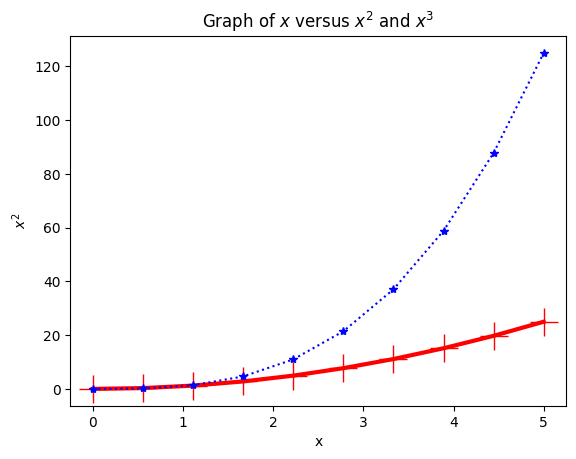

In [ ]:
# 기본 선 그래프
x = np.linspace(0, 5, 10)

plt.figure()
plt.plot(x, x ** 2, color='red', linestyle='-', linewidth=3.0, marker='+', markersize=20.0)
plt.plot(x, x ** 3, 'b:*')        # 축약 표기: 파랑 점선 * 마커
plt.xlabel('x')
plt.ylabel('$x^2$')
plt.title('Graph of $x$ versus $x^2$ and $x^3$')
plt.show()

* 축 범위 설정

   * **plt.xlim(시작, 끝)** : x축 범위
   * **plt.ylim(시작, 끝)** : y축 범위
   * **튜플**로도 가능: plt.xlim((1, 3))

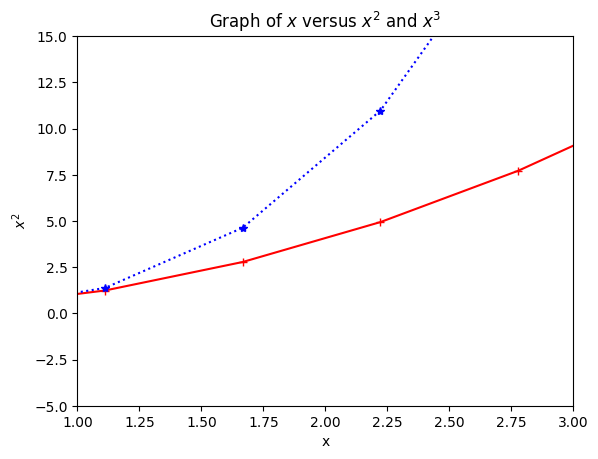

In [ ]:
# 축 범위 설정
plt.figure()
plt.plot(x, x ** 2, 'r-+')
plt.plot(x, x ** 3, 'b:*')
plt.xlabel('x')
plt.ylabel('$x^2$')
plt.title('Graph of $x$ versus $x^2$ and $x^3$')
plt.xlim(1, 3)
plt.ylim(-5, 15)
plt.show()

* 범례 지정

  * **plt.legend(['라벨1', '라벨2'], loc='위치')**
  * 위치 옵션: 'upper left', 'upper right', 'lower left', 'best' 등

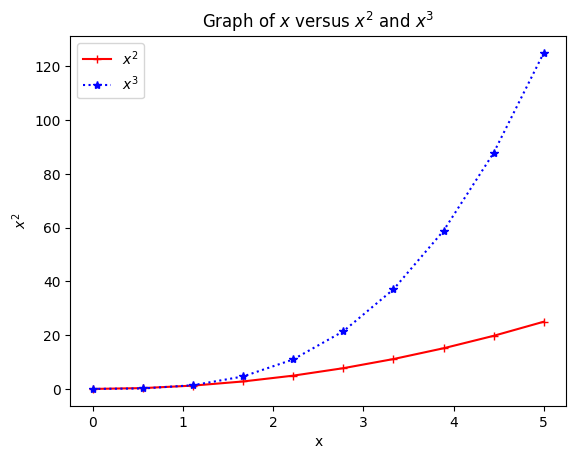

In [ ]:
# 범례 지정
plt.figure()
plt.plot(x, x ** 2, 'r-+')
plt.plot(x, x ** 3, 'b:*')
plt.xlabel('x')
plt.ylabel('$x^2$')
plt.title('Graph of $x$ versus $x^2$ and $x^3$')
plt.legend(['$x^2$', '$x^3$'], loc='upper left')
plt.show()

* 파일 저장

  * **fig.savefig('파일명.png')** : png, pdf, svg, eps 등 다양한 형식 지원
  * fig = plt.figure()로 figure 객체를 변수에 저장해야 사용 가능

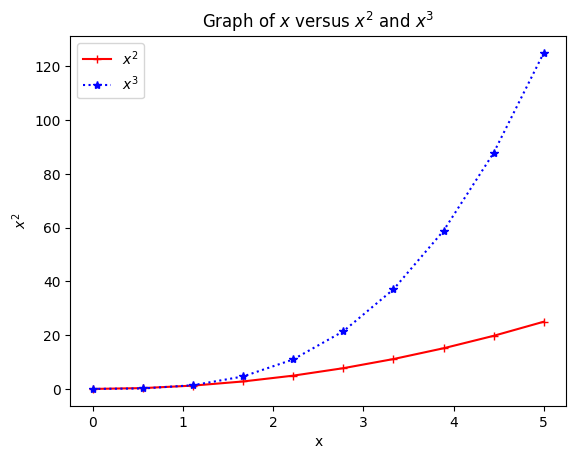

In [ ]:
# 파일 저장
fig = plt.figure()
plt.plot(x, x ** 2, 'r-+')
plt.plot(x, x ** 3, 'b:*')
plt.xlabel('x')
plt.ylabel('$x^2$')
plt.title('Graph of $x$ versus $x^2$ and $x^3$')
plt.legend(['$x^2$', '$x^3$'], loc='upper left')
plt.show()
fig.savefig('graph.png')    # png, pdf, svg, eps 등

* **subplot** : 여러 그래프 한 번에 그리기

  * **fig, axes = plt.subplots(nrows=행수, ncols=열수)**
  * 개별 축에서는 set_xlabel(), set_ylabel(), set_title(), set_xlim(), set_ylim() 을 사용한다. (xlabel()이 아닌 set_xlabel()임에 주의)
  * **fig.tight_layout()** : 그래프 간 겹침 방지

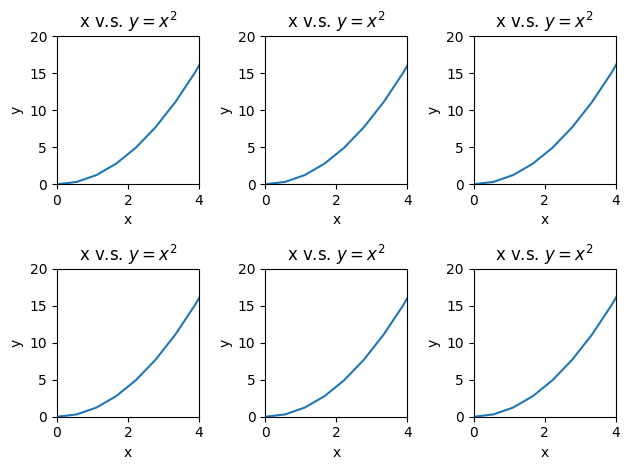

In [ ]:
# subplot: 여러 그래프
fig, axes = plt.subplots(nrows=2, ncols=3)

for row in range(2):
    for col in range(3):
        axe = axes[row][col]
        axe.plot(x, x**2)
        axe.set_xlabel('x')       # NOT xlabel()
        axe.set_ylabel('y')
        axe.set_title('x v.s. $y=x^2$')
        axe.set_xlim((0, 4))
        axe.set_ylim((0, 20))
fig.tight_layout()
plt.show()

* 다양한 plot 종류

  * **scatter()** : 산점도
  * **step()** : 계단형 그래프 (where: pre, post, mid)
  * **bar()** : 막대 그래프
  * **fill_between()** : 두 곡선 사이 영역 채우기
  * **boxplot()** : 박스플롯

    * **showmeans=True** : 평균값 표시
    * **meanline=True** : 평균선 표시
    * **showbox=False, showcaps=False** : Tufte 스타일 (미니멀)

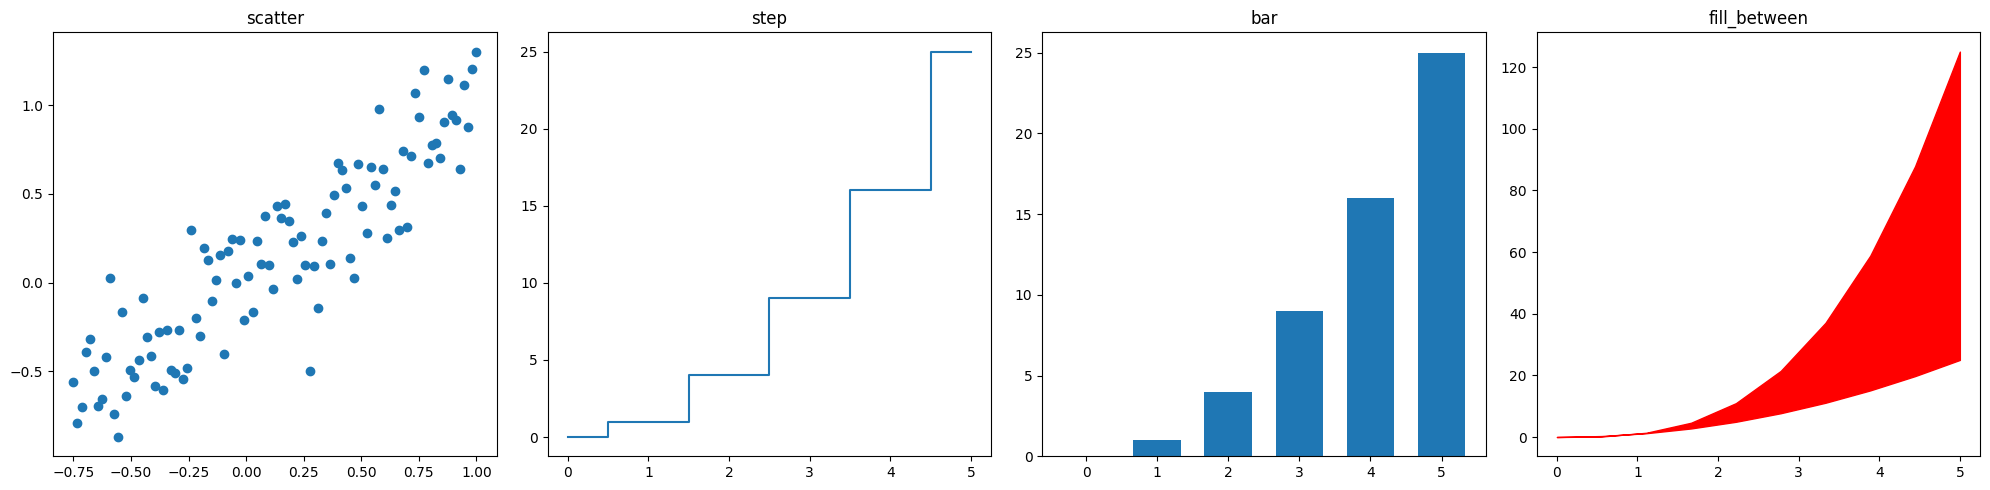

In [ ]:
# 다양한 plot 종류
xx = np.linspace(-0.75, 1., 100)
n = np.array(range(6))

fig, axes = plt.subplots(1, 4, figsize=(20,5))

axes[0].scatter(xx, xx + 0.25 * np.random.randn(len(xx)))
axes[0].set_title('scatter')

axes[1].step(n, n**2, where='mid')    # where: pre, post, mid
axes[1].set_title('step')

axes[2].bar(n, n**2, align='center', width=0.67)
axes[2].set_title('bar')

axes[3].fill_between(x, x**2, x**3, color='red')
axes[3].set_title('fill_between')

fig.tight_layout()
plt.show()

/tmp/ipykernel_7889/2839575877.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot(data, labels=labels)
/tmp/ipykernel_7889/2839575877.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(data, labels=labels, showmeans=True)
/tmp/ipykernel_7889/2839575877.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(data, labels=labels, showmeans=True, meanline=True)
/tmp/ipykernel_7889/2839575877.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.


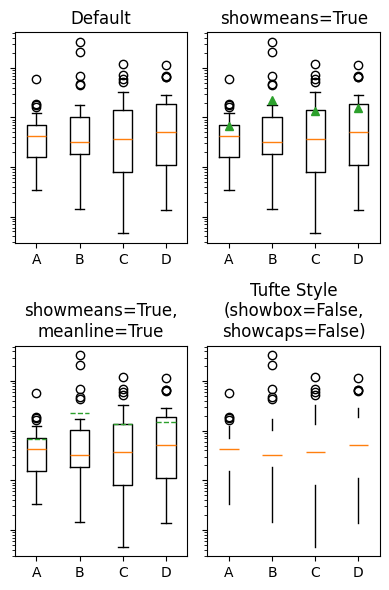

In [ ]:
# boxplot 다양한 스타일
np.random.seed(42)
data = np.random.lognormal(size=(37,4), mean=1.5, sigma=1.75)
labels = list('ABCD')

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(4,6))

axes[0, 0].boxplot(data, labels=labels)
axes[0, 0].set_title('Default')

axes[0, 1].boxplot(data, labels=labels, showmeans=True)
axes[0, 1].set_title('showmeans=True')

axes[1, 0].boxplot(data, labels=labels, showmeans=True, meanline=True)
axes[1, 0].set_title('showmeans=True,\nmeanline=True')

axes[1, 1].boxplot(data, labels=labels, showbox=False, showcaps=False)
axes[1, 1].set_title('Tufte Style\n(showbox=False,\nshowcaps=False)')

for ax in axes.flatten():
    ax.set_yscale('log')
    ax.set_yticklabels([])

fig.tight_layout()
plt.show()

---
## 6.실제 데이터기반 read/write 및 실습

2017년 기준 전 세계 스타벅스 위치 데이터를 기반으로, **용인시의 스타벅스 매장 수** 확인하기

* 데이터 출처: [Kaggle - Starbucks Store Locations](https://www.kaggle.com/datasets/starbucks/store-locations)
* 실습 목표:
  * CSV 파일 읽기 (`pd.read_csv`)
  * 조건 필터링 (`str.contains`, Boolean indexing)
  * 데이터 검증 및 교차 검증
  * DataFrame 병합 (`pd.merge`)
  * CSV 파일 저장 (`to_csv`)
  * 시각화 (`matplotlib`)

* **Step 1: 데이터 읽기 및 기본 탐색**

In [4]:
import pandas as pd
df = pd.read_csv('directory.csv')   # 2017년 기준 전세계 스타벅스 위치 데이터

In [5]:
df.head()

,Brand,Store Number,Store Name,Ownership Type,Street Address,City,State/Province,Country,Postcode,Phone Number,Timezone,Longitude,Latitude
0,Starbucks,47370-257954,"Meritxell, 96",Licensed,"Av. Meritxell, 96",Andorra la Vella,7,AD,AD500,376818720,GMT+1:00 Europe/Andorra,1.53,42.51
1,Starbucks,22331-212325,Ajman Drive Thru,Licensed,"1 Street 69, Al Jarf",Ajman,AJ,AE,NaN,NaN,GMT+04:00 Asia/Dubai,55.47,25.42
2,Starbucks,47089-256771,Dana Mall,Licensed,Sheikh Khalifa Bin Zayed St.,Ajman,AJ,AE,NaN,NaN,GMT+04:00 Asia/Dubai,55.47,25.39
3,Starbucks,22126-218024,Twofour 54,Licensed,Al Salam Street,Abu Dhabi,AZ,AE,NaN,NaN,GMT+04:00 Asia/Dubai,54.38,24.48
4,Starbucks,17127-178586,Al Ain Tower,Licensed,"Khaldiya Area, Abu Dhabi Island",Abu Dhabi,AZ,AE,NaN,NaN,GMT+04:00 Asia/Dubai,54.54,24.51


In [6]:
print("--- 데이터 기본 정보 ---")
print(df.info()) # 13개의 컬럼과 25,600여 개의 행 확인

--- 데이터 기본 정보 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25600 entries, 0 to 25599
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           25600 non-null  object 
 1   Store Number    25600 non-null  object 
 2   Store Name      25600 non-null  object 
 3   Ownership Type  25600 non-null  object 
 4   Street Address  25598 non-null  object 
 5   City            25585 non-null  object 
 6   State/Province  25600 non-null  object 
 7   Country         25600 non-null  object 
 8   Postcode        24078 non-null  object 
 9   Phone Number    18739 non-null  object 
 10  Timezone        25600 non-null  object 
 11  Longitude       25599 non-null  float64
 12  Latitude        25599 non-null  float64
dtypes: float64(2), object(11)
memory usage: 2.5+ MB
None


In [7]:
print("\n--- 국가별 매장 수 Top 5 ---")
print(df['Country'].value_counts().head(5))


--- 국가별 매장 수 Top 5 ---
Country
US    13608
CN     2734
CA     1468
JP     1237
KR      993
Name: count, dtype: int64


* **Step 2: 한국 및 용인시 데이터 추출**

In [8]:
# 한국 국가 코드 'KR' 필터링
korea_df = df[df['Country'] == 'KR'].copy()
korea_df

,Brand,Store Number,Store Name,Ownership Type,Street Address,City,State/Province,Country,Postcode,Phone Number,Timezone,Longitude,Latitude
7980,Starbucks,20644-207432,Lafesta Square,Joint Venture,"770-1, Janghangdong, Ilsandonggu, Goyangshi, G...",Gyeonggido,11,KR,410-380,NaN,GMT+09:00 Asia/Seoul,126.46,37.39
7981,Starbucks,28417-250406,bangbae cafe golmok,Joint Venture,777-11 bangbae-dong,seocho-gu,11,KR,137-829,NaN,GMT+09:00 Asia/Seoul,126.99,37.49
7982,Starbucks,19176-199455,Wolgae Emart,Joint Venture,"333-1 Wolgae3dong, Nowongu, Seoul",Seoul,11,KR,139-050,NaN,GMT+09:00 Asia/Seoul,127.06,37.63
7983,Starbucks,23428-230106,Olympic Park North Gate,Joint Venture,"468 Seongnae-dong,Gangdong-gu",Seoul,11,KR,134-848,NaN,GMT+09:00 Asia/Seoul,127.13,37.53
7984,Starbucks,49283-267704,Mia Newtown,Joint Venture,"812-2, Mia-dong, Gangbuk-gu",Seoul,11,KR,1195,NaN,GMT+09:00 Asia/Seoul,127.02,37.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8968,Starbucks,17728-182446,Seongsan Ilchulbong,Joint Venture,"109-11, Seongsan-ri, Seongsan-eup",Seogwipo,49,KR,699-903,NaN,GMT+09:00 Asia/Seoul,126.94,33.46
8969,Starbucks,17479-182447,Jeju Jungmun,Joint Venture,"2864-2, Saekdal-dong",Seogwipo,49,KR,697-808,NaN,GMT+09:00 Asia/Seoul,126.41,33.25
8970,Starbucks,17934-187324,Jeju Seogwipo,Joint Venture,"293-9, Seogwi-dong, Jeju-do District",Seogwipo-si,49,KR,697-842,NaN,GMT+09:00 Asia/Seoul,126.56,33.25
8971,Starbucks,23970-233826,Jeju Seogwipo DT,Joint Venture,"231-6, 246, 248-1, Gangjeong-dong",Seogwipo-si,49,KR,697-827,NaN,GMT+09:00 Asia/Seoul,126.51,33.25


In [9]:
# 용인시 데이터 추출 (영문 데이터이므로 'Yongin' 키워드 검색)
# 데이터에 따라 'Yongin-si' 또는 'Yongin'으로 되어있을 수 있어 contains 사용
yongin_df = korea_df[korea_df['City'].str.contains('Yongin|용인', case=False, na=False)].copy()
yongin_df

,Brand,Store Number,Store Name,Ownership Type,Street Address,City,State/Province,Country,Postcode,Phone Number,Timezone,Longitude,Latitude
8664,Starbucks,19269-200266,Yongin Jungbudaero,Joint Venture,522-2/523-2 Yeongduk-dong,"Giheung-gu,Yongin",41,KR,446-908,NaN,GMT+09:00 Asia/Seoul,127.07,37.29
8782,Starbucks,15013-157125,Suji E-mart,Joint Venture,"909, Shinbong-Dong, Suji-Gu",Yongin,41,KR,448-150,NaN,GMT+09:00 Asia/Seoul,127.08,37.32
8783,Starbucks,16986-176547,Suji-poongdukchun,Joint Venture,"1080-11 Poongdukchun-dong, Suji-gu",Yongin,41,KR,448-509,NaN,GMT+09:00 Asia/Seoul,127.10,37.32
8784,Starbucks,13064-156086,Guseong E-Mart - Closed,Joint Venture,"1019-237, Bojeong-Dong, Giheung-Gu",Yongin,41,KR,446-913,NaN,GMT+09:00 Asia/Seoul,127.11,37.31
8785,Starbucks,19069-198164,Yongin Bojeong,Joint Venture,"1263 bojeong-dong, Kyonggi-do District",Yongin,41,KR,446-858,NaN,GMT+09:00 Asia/Seoul,127.11,37.32
8786,Starbucks,29809-255306,Yongin City Hall DT,Joint Venture,"samga-dong, cheoin-gu",Yongin-si,41,KR,17091,NaN,GMT+09:00 Asia/Seoul,127.17,37.24
8787,Starbucks,22178-218224,Yongin Giheung-gu Office,Joint Venture,"86 Sin-gal-dong, Giheung-gu, Yongin-si",Yongin-si,41,KR,446-907,NaN,GMT+09:00 Asia/Seoul,127.11,37.28
8788,Starbucks,24278-236645,Suji Dongcheon,Joint Venture,"946-2, Dongcheon-dong, Suji-gu",Yongin-si,41,KR,448-120,NaN,GMT+09:00 Asia/Seoul,127.09,37.34
8789,Starbucks,23703-232545,Suji Jukjeon,Joint Venture,"1191-2 Jukjeon-dong, Suji-gu",Yongin-si,41,KR,448-808,NaN,GMT+09:00 Asia/Seoul,127.12,37.33
8790,Starbucks,25859-242525,Yongin Mabuk DT,Joint Venture,"502-152, Mabuk-dong",Yongin-si,41,KR,446-912,NaN,GMT+09:00 Asia/Seoul,127.11,37.29


In [10]:
len(yongin_df)

11

* **Step 3: 데이터 검증**

2017년 기준 11개의 스타벅스 매장이 있다? → 빠진 부분은 없는지 **데이터 검증 절차** 추가

* City 라벨이 통일되지 않아 누락 가능성 존재
* `State/Province` 기준으로 경기도(41) 데이터를 먼저 확인 후, 키워드 기반 교차 검증

In [11]:
print("\n--- 한국 내 스타벅스 보유 도시 Top 10 ---")
print(korea_df['City'].value_counts().head(10))
# 서울, Seoul 다르게 라벨링되어 있고, 경기도가 단 24개 매장? → 데이터 불완전성


--- 한국 내 스타벅스 보유 도시 Top 10 ---
City
Seoul      243
서울         136
Busan       67
Daegu       38
Daejeon     30
Incheon     29
Gwangju     27
경기도         24
Ulsan       16
부산          16
Name: count, dtype: int64


In [12]:
# State/Province 기준으로 경기도 데이터 다시 확인
gyeonggi_df = korea_df[korea_df['State/Province'].astype(str) == '41'].copy()
gyeonggi_df

,Brand,Store Number,Store Name,Ownership Type,Street Address,City,State/Province,Country,Postcode,Phone Number,Timezone,Longitude,Latitude
8638,Starbucks,17591-183704,Ansan Traders,Joint Venture,"Singil-dong, Danwon-gu, 1F",Ansan,41,KR,425-120,NaN,GMT+09:00 Asia/Seoul,126.78,37.33
8639,Starbucks,21364-212067,Ansan Jungang,Joint Venture,"539-1, Gojan 2-dong, Danwon-gu, Hannam Building",Ansan,41,KR,425-868,NaN,GMT+09:00 Asia/Seoul,126.55,37.21
8640,Starbucks,21098-209350,Ansan Handae station,Joint Venture,"715-2. I-dong Sangnok-gu, Ansan-si, Gyeonggi-do",Ansan,41,KR,426-863,NaN,GMT+09:00 Asia/Seoul,126.56,37.21
8641,Starbucks,16197-169044,Ansan Gojan,Joint Venture,"536 Gojan 2-dong, Danwon-gu",Ansan,41,KR,425-868,NaN,GMT+09:00 Asia/Seoul,126.83,37.32
8642,Starbucks,25853-238065,Gojan E-mart,Joint Venture,"741-6, Choji-dong, Danwon-gu",Ansan-si,41,KR,425-826,NaN,GMT+09:00 Asia/Seoul,126.81,37.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8814,Starbucks,31733-116546,주엽사거리점,Joint Venture,주엽동 18-2 서현프라자 112~114,경기도,41,KR,411-370,031-913-8206,GMT+09:00 Asia/Seoul,126.76,37.67
8815,Starbucks,34453-80622,안양1번가점,Joint Venture,안양동 674-170,경기도,41,KR,430-010,031-443-0346,GMT+09:00 Asia/Seoul,126.92,37.40
8816,Starbucks,1900-141785,의정부중앙점,Joint Venture,195-8,경기도,41,KR,480-010,031-821-7275,GMT+09:00 Asia/Seoul,127.05,37.74
8817,Starbucks,31720-114024,여주첼시점,Joint Venture,상거리 15-1,경기도,41,KR,469-803,031-880-1633,GMT+09:00 Asia/Seoul,127.61,37.24


In [13]:
len(gyeonggi_df)  ### absolutely not 24

181

* **Step 4: 교차 검증 — 키워드 확장 검색**

**첫 번째 검증**: 도시명 + 상호명에서 용인 관련 키워드(수지, 기흥, 처인 포함) 확장 검색

In [14]:
yongin_keywords = 'Yongin|용인|Suji|수지|Giheung|기흥|Cheoin|처인'

real_yongin_df = gyeonggi_df[
    gyeonggi_df['City'].str.contains(yongin_keywords, case=False, na=False) |
    gyeonggi_df['Store Name'].str.contains(yongin_keywords, case=False, na=False)
].copy()

real_yongin_df

,Brand,Store Number,Store Name,Ownership Type,Street Address,City,State/Province,Country,Postcode,Phone Number,Timezone,Longitude,Latitude
8664,Starbucks,19269-200266,Yongin Jungbudaero,Joint Venture,522-2/523-2 Yeongduk-dong,"Giheung-gu,Yongin",41,KR,446-908,NaN,GMT+09:00 Asia/Seoul,127.07,37.29
8704,Starbucks,27344-247247,Yongin Dongbaek DT,Joint Venture,"461-2, Sangha-dong, Giheung-gu, Yongin-s",GYEONGGI,41,KR,NaN,NaN,GMT+09:00 Asia/Seoul,127.14,37.27
8782,Starbucks,15013-157125,Suji E-mart,Joint Venture,"909, Shinbong-Dong, Suji-Gu",Yongin,41,KR,448-150,NaN,GMT+09:00 Asia/Seoul,127.08,37.32
8783,Starbucks,16986-176547,Suji-poongdukchun,Joint Venture,"1080-11 Poongdukchun-dong, Suji-gu",Yongin,41,KR,448-509,NaN,GMT+09:00 Asia/Seoul,127.10,37.32
8784,Starbucks,13064-156086,Guseong E-Mart - Closed,Joint Venture,"1019-237, Bojeong-Dong, Giheung-Gu",Yongin,41,KR,446-913,NaN,GMT+09:00 Asia/Seoul,127.11,37.31
8785,Starbucks,19069-198164,Yongin Bojeong,Joint Venture,"1263 bojeong-dong, Kyonggi-do District",Yongin,41,KR,446-858,NaN,GMT+09:00 Asia/Seoul,127.11,37.32
8786,Starbucks,29809-255306,Yongin City Hall DT,Joint Venture,"samga-dong, cheoin-gu",Yongin-si,41,KR,17091,NaN,GMT+09:00 Asia/Seoul,127.17,37.24
8787,Starbucks,22178-218224,Yongin Giheung-gu Office,Joint Venture,"86 Sin-gal-dong, Giheung-gu, Yongin-si",Yongin-si,41,KR,446-907,NaN,GMT+09:00 Asia/Seoul,127.11,37.28
8788,Starbucks,24278-236645,Suji Dongcheon,Joint Venture,"946-2, Dongcheon-dong, Suji-gu",Yongin-si,41,KR,448-120,NaN,GMT+09:00 Asia/Seoul,127.09,37.34
8789,Starbucks,23703-232545,Suji Jukjeon,Joint Venture,"1191-2 Jukjeon-dong, Suji-gu",Yongin-si,41,KR,448-808,NaN,GMT+09:00 Asia/Seoul,127.12,37.33


In [15]:
len(real_yongin_df)  # 1개 누락 발견

12

**두 번째 검증**: `Street Address` 기준으로 찾아보면 더 정확하지 않을까?

In [16]:
hidden_yongin = gyeonggi_df[
    gyeonggi_df['Street Address'].str.contains('Yongin|용인|Suji|수지|Giheung|기흥|Cheoin|처인', case=False, na=False)
]
print(f"주소로 새로 찾은 매장 수: {len(hidden_yongin)}개")
hidden_yongin

주소로 새로 찾은 매장 수: 11개


,Brand,Store Number,Store Name,Ownership Type,Street Address,City,State/Province,Country,Postcode,Phone Number,Timezone,Longitude,Latitude
8663,Starbucks,20922-209005,Youngin Gu-office,Joint Venture,"295-9 Kimryangjang-dong, Cheoin-gu District",Geonggi-do,41,KR,449-925,NaN,GMT+09:00 Asia/Seoul,127.12,37.15
8704,Starbucks,27344-247247,Yongin Dongbaek DT,Joint Venture,"461-2, Sangha-dong, Giheung-gu, Yongin-s",GYEONGGI,41,KR,NaN,NaN,GMT+09:00 Asia/Seoul,127.14,37.27
8705,Starbucks,20506-206325,Gwanggyo sindae station,Joint Venture,"1119-1 sanghyun-dong, suji- gu, Yongin-si Dist...",Gyeonggi-do,41,KR,448-130,NaN,GMT+09:00 Asia/Seoul,127.49,37.18
8782,Starbucks,15013-157125,Suji E-mart,Joint Venture,"909, Shinbong-Dong, Suji-Gu",Yongin,41,KR,448-150,NaN,GMT+09:00 Asia/Seoul,127.08,37.32
8783,Starbucks,16986-176547,Suji-poongdukchun,Joint Venture,"1080-11 Poongdukchun-dong, Suji-gu",Yongin,41,KR,448-509,NaN,GMT+09:00 Asia/Seoul,127.10,37.32
8784,Starbucks,13064-156086,Guseong E-Mart - Closed,Joint Venture,"1019-237, Bojeong-Dong, Giheung-Gu",Yongin,41,KR,446-913,NaN,GMT+09:00 Asia/Seoul,127.11,37.31
8786,Starbucks,29809-255306,Yongin City Hall DT,Joint Venture,"samga-dong, cheoin-gu",Yongin-si,41,KR,17091,NaN,GMT+09:00 Asia/Seoul,127.17,37.24
8787,Starbucks,22178-218224,Yongin Giheung-gu Office,Joint Venture,"86 Sin-gal-dong, Giheung-gu, Yongin-si",Yongin-si,41,KR,446-907,NaN,GMT+09:00 Asia/Seoul,127.11,37.28
8788,Starbucks,24278-236645,Suji Dongcheon,Joint Venture,"946-2, Dongcheon-dong, Suji-gu",Yongin-si,41,KR,448-120,NaN,GMT+09:00 Asia/Seoul,127.09,37.34
8789,Starbucks,23703-232545,Suji Jukjeon,Joint Venture,"1191-2 Jukjeon-dong, Suji-gu",Yongin-si,41,KR,448-808,NaN,GMT+09:00 Asia/Seoul,127.12,37.33


* **Step 5: 검증 결과 병합 (merge) 및 CSV 저장**

두 가지 검증방법으로 찾은 데이터를 `pd.merge`로 합치기

In [17]:
combined_yongin = pd.merge(real_yongin_df, hidden_yongin, how='outer', left_index=False, right_index=False)
combined_yongin

,Brand,Store Number,Store Name,Ownership Type,Street Address,City,State/Province,Country,Postcode,Phone Number,Timezone,Longitude,Latitude
0,Starbucks,13064-156086,Guseong E-Mart - Closed,Joint Venture,"1019-237, Bojeong-Dong, Giheung-Gu",Yongin,41,KR,446-913,NaN,GMT+09:00 Asia/Seoul,127.11,37.31
1,Starbucks,15013-157125,Suji E-mart,Joint Venture,"909, Shinbong-Dong, Suji-Gu",Yongin,41,KR,448-150,NaN,GMT+09:00 Asia/Seoul,127.08,37.32
2,Starbucks,16986-176547,Suji-poongdukchun,Joint Venture,"1080-11 Poongdukchun-dong, Suji-gu",Yongin,41,KR,448-509,NaN,GMT+09:00 Asia/Seoul,127.10,37.32
3,Starbucks,19069-198164,Yongin Bojeong,Joint Venture,"1263 bojeong-dong, Kyonggi-do District",Yongin,41,KR,446-858,NaN,GMT+09:00 Asia/Seoul,127.11,37.32
4,Starbucks,19269-200266,Yongin Jungbudaero,Joint Venture,522-2/523-2 Yeongduk-dong,"Giheung-gu,Yongin",41,KR,446-908,NaN,GMT+09:00 Asia/Seoul,127.07,37.29
5,Starbucks,20506-206325,Gwanggyo sindae station,Joint Venture,"1119-1 sanghyun-dong, suji- gu, Yongin-si Dist...",Gyeonggi-do,41,KR,448-130,NaN,GMT+09:00 Asia/Seoul,127.49,37.18
6,Starbucks,20922-209005,Youngin Gu-office,Joint Venture,"295-9 Kimryangjang-dong, Cheoin-gu District",Geonggi-do,41,KR,449-925,NaN,GMT+09:00 Asia/Seoul,127.12,37.15
7,Starbucks,22178-218224,Yongin Giheung-gu Office,Joint Venture,"86 Sin-gal-dong, Giheung-gu, Yongin-si",Yongin-si,41,KR,446-907,NaN,GMT+09:00 Asia/Seoul,127.11,37.28
8,Starbucks,22629-223150,Suji Seongbok DT,Joint Venture,"83-2, Seongbok-dong, Suji-gu",Yongin-si,41,KR,448-830,NaN,GMT+09:00 Asia/Seoul,127.08,37.31
9,Starbucks,23703-232545,Suji Jukjeon,Joint Venture,"1191-2 Jukjeon-dong, Suji-gu",Yongin-si,41,KR,448-808,NaN,GMT+09:00 Asia/Seoul,127.12,37.33


In [20]:
len(combined_yongin)  # 최종 14개의 2017년 용인시 스타벅스 점포 확인

14

In [21]:
# CSV 파일로 저장
combined_yongin.to_csv('starbucks_yongin_list.csv', index=False)
print("\n'starbucks_yongin_list.csv' 저장 완료.")


'starbucks_yongin_list.csv' 저장 완료.


* **Step 6: 시각화 -> 용인시 구별 스타벅스 점포 수**

   *`apply()` 함수로 주소에서 구 정보를 추출하여 새로운 컬럼 생성
   * `value_counts()`로 구별 집계
   * `plt.barh()`로 가로 막대 그래프 시각화

In [22]:
# 1. '구' 정보를 추출하여 새로운 컬럼 만들기
def get_district(address):
    if 'Suji' in address or '수지' in address: return '수지구'
    if 'Giheung' in address or '기흥' in address: return '기흥구'
    if 'Cheoin' in address or '처인' in address: return '처인구'
    return '기타'

combined_yongin['District'] = combined_yongin['Street Address'].apply(get_district)

In [23]:
district_counts = combined_yongin['District'].value_counts()
district_counts

,count
District,
수지구,5
기타,5
기흥구,3
처인구,1


/tmp/ipykernel_10326/528065445.py:21: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10326/528065445.py:21: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10326/528065445.py:21: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10326/528065445.py:21: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10326/528065445.py:21: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10326/528065445.py:21: UserWarning: Glyph 55141 (\N{HANGUL SYLLABLE HEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10326/528065445.py:21: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  plt.tight_layo

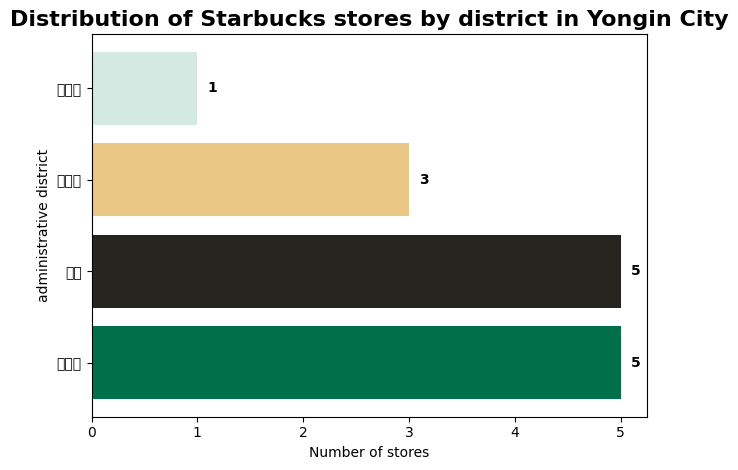

In [36]:
labels = district_counts.index
values = district_counts.values

plt.rc('font', family='Malgun Gothic')
plt.figure()

# 가로 막대 그래프 그리기 (Horizontal Bar Chart)
colors = ['#00704A', '#27251F', '#EAC784', '#D4E9E2'] # 스타벅스 브랜드 컬러 활용

plt.barh(labels, values, color=colors[:len(labels)])

# 세부 설정 (plt 명령어들)
plt.title('Distribution of Starbucks stores by district in Yongin City', fontsize=16, fontweight='bold')
plt.xlabel('Number of stores')
plt.ylabel('administrative district')

# 각 막대 끝에 숫자 표시
for i, v in enumerate(district_counts):
    plt.text(v + 0.1, i, f'{v}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

* 실습 핵심 정리

   * **데이터 읽기/쓰기**: `pd.read_csv()` → 분석 → `df.to_csv()`
   * **조건 필터링**: `df[df['열'] == '값']`, `str.contains()`로 부분 문자열 매칭
   * **데이터 검증**: 하나의 기준으로만 필터링하면 누락 발생 → **교차 검증**(City, Store Name, Street Address 등 여러 열 활용) 필요
   * **데이터 병합**: `pd.merge(how='outer')`로 서로 다른 방법으로 찾은 데이터 합치기
   * **데이터 정제**: `apply()` + 사용자 정의 함수로 새 열 생성
   * **시각화**: `plt.barh()`로 가로 막대 그래프, `plt.text()`로 값 라벨 표시